# Week 5 live coding: random forest regression on electricity demand

How much electricity does New York City use when it is 35 °C? When it is −10 °C? The answer
is a curve, not a line: demand climbs in the cold for heating and climbs faster in the heat for
air conditioning, with a minimum somewhere in the mild middle. Week 4's linear regression
cannot draw a curve like that. Trees can, and this tutorial shows how, then shows the one thing
trees cannot do, which matters for every climate application you will meet.

Two public data sets, joined by the hour:

- **NYISO**, the New York grid operator, publishes the actual load of each zone every hour.
  We take the New York City zone.
- **NOAA** publishes hourly temperature at Central Park, the same station as Week 4.

Six years, 2019 to 2024, about 52,000 hours.


In [1]:
import io
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Build the data set

NYISO ships one zip archive per month, each holding one CSV per day with every zone's hourly
load. The loop below fetches 72 archives and keeps the New York City rows. NOAA's hourly feed
returns a temperature field encoded as text, such as `+0228,5`: tenths of a degree Celsius, then
a quality flag. Both feeds take about twenty seconds. The cell saves the joined table to a CSV
so later runs skip the download.


In [2]:
FILE = "nyc_load_temp_hourly.csv"

if not os.path.exists(FILE):
    # --- NYISO hourly integrated load, New York City zone
    frames = []
    for year in range(2019, 2025):
        for month in range(1, 13):
            url = f"http://mis.nyiso.com/public/csv/palIntegrated/{year}{month:02d}01palIntegrated_csv.zip"
            archive = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read()))
            for name in archive.namelist():
                day = pd.read_csv(archive.open(name))
                frames.append(day[day["Name"] == "N.Y.C."])
    load = pd.concat(frames, ignore_index=True)
    stamp = pd.to_datetime(load["Time Stamp"], format="%m/%d/%Y %H:%M:%S")
    offset = np.where(load["Time Zone"] == "EDT", 4, 5)          # hours behind UTC
    load["time_utc"] = stamp + pd.to_timedelta(offset, unit="h")
    load = load.rename(columns={"Integrated Load": "load_MW"})[["time_utc", "load_MW"]]

    # --- NOAA hourly temperature at Central Park (station 72505394728), stamps in UTC
    pieces = []
    for year in range(2019, 2025):
        url = ("https://www.ncei.noaa.gov/access/services/data/v1?dataset=global-hourly"
               f"&stations=72505394728&startDate={year}-01-01&endDate={year}-12-31&dataTypes=TMP&format=csv")
        pieces.append(pd.read_csv(url, usecols=["DATE", "TMP"]))
    obs = pd.concat(pieces, ignore_index=True)
    value, quality = obs["TMP"].str.split(",", expand=True)[0], obs["TMP"].str.split(",", expand=True)[1]
    obs = obs[(value != "+9999") & quality.isin(["1", "5"])].copy()      # drop missing and suspect readings
    obs["temp_C"] = value[obs.index].astype(float) / 10
    obs["time_utc"] = pd.to_datetime(obs["DATE"]).dt.floor("h")
    temp = obs.groupby("time_utc")["temp_C"].mean().reset_index()

    df = load.merge(temp, on="time_utc", how="inner").sort_values("time_utc")
    df.to_csv(FILE, index=False)

df = pd.read_csv(FILE, parse_dates=["time_utc"])
print(df.shape)

(52439, 3)


The timestamps are in UTC so the two feeds line up. Demand follows the local clock, so the
features come from local time: hour of day, day of week, and day of year.


In [3]:
local = df["time_utc"].dt.tz_localize("UTC").dt.tz_convert("America/New_York")
df["hour"] = local.dt.hour
df["dayofweek"] = local.dt.dayofweek        # Monday = 0
df["doy"] = local.dt.dayofyear
df["year"] = local.dt.year

print(f"{len(df):,} hours from {local.min().date()} to {local.max().date()}")
print(f"temperature {df['temp_C'].min():.1f} to {df['temp_C'].max():.1f} °C, "
      f"load {df['load_MW'].min():,.0f} to {df['load_MW'].max():,.0f} MW")
df.head()

52,439 hours from 2019-01-01 to 2024-12-31
temperature -16.7 to 36.1 °C, load 3,604 to 10,830 MW


,time_utc,load_MW,temp_C,hour,dayofweek,doy,year
0,2019-01-01 05:00:00,4896.0,8.375,0,1,1,2019
1,2019-01-01 06:00:00,4719.6,10.000,1,1,1,2019
2,2019-01-01 07:00:00,4532.9,11.100,2,1,1,2019
3,2019-01-01 08:00:00,4395.6,10.150,3,1,1,2019
4,2019-01-01 09:00:00,4322.6,11.150,4,1,1,2019


## 2. Look at the data first

Demand against temperature, every hour of six years. Colour is the hour of day.


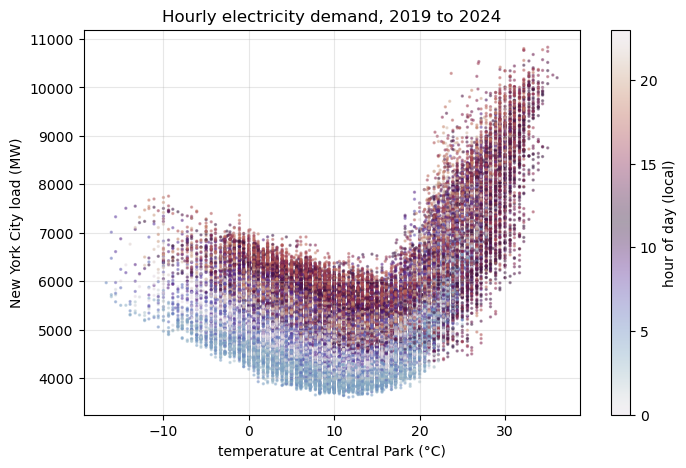

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df["temp_C"], df["load_MW"], c=df["hour"], cmap="twilight", s=2, alpha=0.4)
fig.colorbar(sc, ax=ax, label="hour of day (local)")
ax.set_xlabel("temperature at Central Park (°C)")
ax.set_ylabel("New York City load (MW)")
ax.set_title("Hourly electricity demand, 2019 to 2024")
ax.grid(alpha=0.3)
plt.show()

Two things to see. The cloud is a U, or more exactly a hockey stick: demand drifts down as
temperature rises through the cool range, bottoms out around 15 °C, then climbs steeply above
20 °C as air conditioning switches on. And the colour shows a second structure stacked on the
first, the daily cycle: at any temperature, afternoon hours sit above small-hours ones. A model
has to capture both, and their interaction, since a hot afternoon is worse than a hot night.

Averaging within temperature bins at one hour of day makes the shape explicit.


In [5]:
afternoon = df[df["hour"] == 16]
bins = pd.cut(afternoon["temp_C"], np.arange(-15, 40, 5))
by_bin = afternoon.groupby(bins, observed=True)["load_MW"].mean()
print("mean 4 pm load by temperature bin (MW):")
print(by_bin.round(0).to_string())

mean 4 pm load by temperature bin (MW):
temp_C
(-15, -10]    7019.0
(-10, -5]     6779.0
(-5, 0]       6427.0
(0, 5]        6088.0
(5, 10]       5726.0
(10, 15]      5430.0
(15, 20]      5480.0
(20, 25]      6445.0
(25, 30]      7769.0
(30, 35]      9243.0


## 3. Split by time

Train on 2019 to 2022, choose settings on 2023, and report on 2024. Demand has a trend and the
weather has runs of similar days, so a random shuffle would let the model see the day either
side of every test hour. The split follows the calendar instead.


In [6]:
features = ["temp_C", "hour", "dayofweek", "doy"]
train = df[df["year"] <= 2022]
val = df[df["year"] == 2023]
test = df[df["year"] == 2024]

X_train, y_train = train[features].values, train["load_MW"].values
X_val, y_val = val[features].values, val["load_MW"].values
X_test, y_test = test[features].values, test["load_MW"].values
print("train", X_train.shape, " val", X_val.shape, " test", X_test.shape)

train (34963, 4)  val (8742, 4)  test (8734, 4)


## 4. Two baselines: the mean, and Week 4's straight line

Every number below is a root mean squared error in megawatts on the validation year. Predicting
the training mean every hour is the floor. Linear regression is the Week 4 model, and it is the
one to beat.


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

mean_pred = np.full(len(y_val), y_train.mean())
print(f"predict the mean:   validation RMSE = {rmse(y_val, mean_pred):,.0f} MW")

lin = LinearRegression().fit(X_train, y_train)
print(f"linear regression:  validation RMSE = {rmse(y_val, lin.predict(X_val)):,.0f} MW")
for name, w in zip(features, lin.coef_):
    print(f"   {name:10s} {w:+8.1f} MW per unit")

predict the mean:   validation RMSE = 1,109 MW
linear regression:  validation RMSE = 851 MW
   temp_C        +60.1 MW per unit
   hour          +55.0 MW per unit
   dayofweek     -97.9 MW per unit
   doy            -0.9 MW per unit


The straight line takes a quarter off the mean baseline and no more, and the coefficients say
why: it has decided that demand rises 60 MW for every degree, everywhere. That is wrong on
cold days, where demand falls as it warms, and far too small on hot ones. A line through a U
is the average of two opposite slopes. No amount of data fixes that; the model family cannot
represent the shape.

## 5. A regression tree

A tree asks threshold questions and, at each leaf, predicts the **mean load of the training
hours that landed there**. That is the only difference from the classification trees in the
notes: leaves hold an average instead of a majority vote, and splits are chosen to reduce the
squared error instead of the impurity.


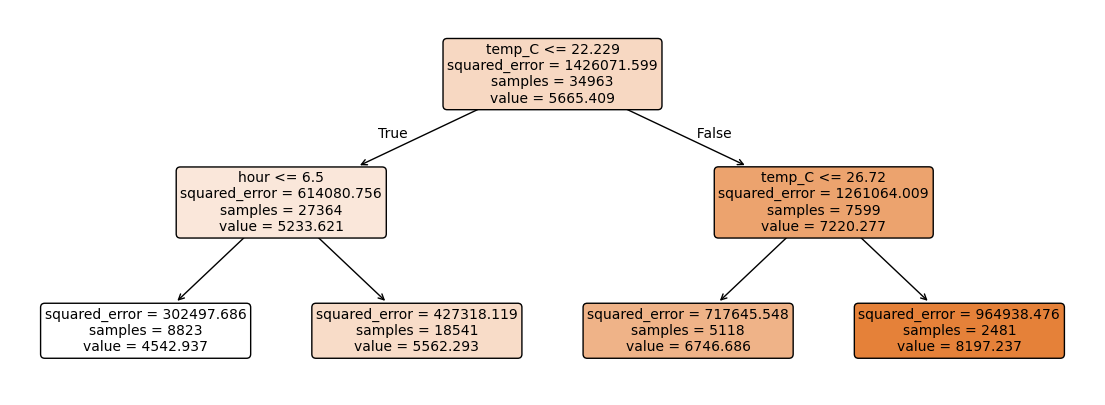

depth-2 tree: validation RMSE = 635 MW


In [8]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

tree2 = DecisionTreeRegressor(max_depth=2, random_state=42).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(tree2, feature_names=features, filled=True, rounded=True, fontsize=10, ax=ax)
plt.show()
print(f"depth-2 tree: validation RMSE = {rmse(y_val, tree2.predict(X_val)):,.0f} MW")

Two questions, and the tree has already beaten the straight line. Read it: the root splits on
temperature at 22 °C, the foot of the hot side of the U. Below that, the cool branch splits on
the hour, separating the small hours from the day, and the hot branch splits on temperature
again at 27 °C, where air conditioning load takes off. The `value` in each leaf is the mean load
of its hours, and `squared_error` is the variance of the load within the node, the thing each
split tries to shrink.

**Depth is the knob.** Let the tree grow and score it on both the training and validation
years.


max_depth=   2  leaves=     4  train RMSE   690  validation RMSE   635
max_depth=   4  leaves=    16  train RMSE   554  validation RMSE   516
max_depth=   6  leaves=    64  train RMSE   445  validation RMSE   415
max_depth=   8  leaves=   251  train RMSE   376  validation RMSE   381


max_depth=  10  leaves=   934  train RMSE   328  validation RMSE   371
max_depth=  12  leaves= 2,880  train RMSE   282  validation RMSE   375
max_depth=  16  leaves=12,128  train RMSE   185  validation RMSE   423


max_depth=  20  leaves=23,623  train RMSE   106  validation RMSE   448


max_depth=None  leaves=34,960  train RMSE     1  validation RMSE   455


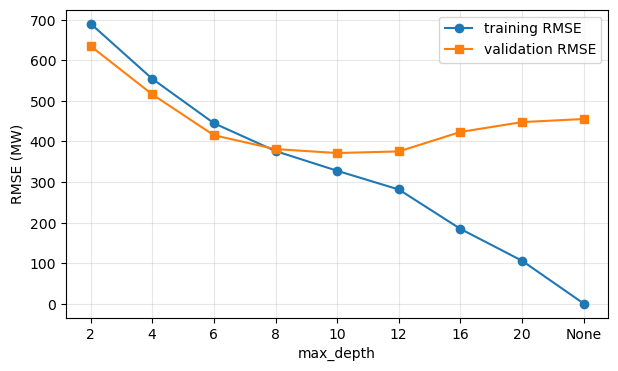

best depth on validation: 10


In [9]:
depths = [2, 4, 6, 8, 10, 12, 16, 20, None]
train_rmse, val_rmse, trees = [], [], {}
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train, y_train)
    trees[d] = t
    train_rmse.append(rmse(y_train, t.predict(X_train)))
    val_rmse.append(rmse(y_val, t.predict(X_val)))
    print(f"max_depth={str(d):>4}  leaves={t.get_n_leaves():>6,}  train RMSE {train_rmse[-1]:>5,.0f}  validation RMSE {val_rmse[-1]:>5,.0f}")

labels = [str(d) for d in depths]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(labels, train_rmse, "o-", label="training RMSE")
ax.plot(labels, val_rmse, "s-", label="validation RMSE")
ax.set_xlabel("max_depth"); ax.set_ylabel("RMSE (MW)"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

best_depth = depths[int(np.argmin(val_rmse))]
best_tree = trees[best_depth]
print("best depth on validation:", best_depth)

Training error falls all the way to zero, because an unlimited tree puts every training hour
in its own leaf and reproduces it exactly. Validation error falls, bottoms out around depth 10
to 12, then rises again as the extra splits fit the noise of individual hours. The gap between
the curves is the overfit. The depth is chosen where the validation curve is lowest, and never
from the training curve, which would always say "deeper".

## 6. A random forest

A single tree at the right depth is good but jumpy: move the split points a little and the
predictions change in steps. A forest grows a hundred fully grown trees, each on a bootstrap
sample of the hours and each considering a random subset of the features at every split, then
averages their predictions. The individual trees overfit; the average does not.


In [10]:
from sklearn.ensemble import RandomForestRegressor
import time

start = time.time()
forest = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
print(f"trained 100 trees in {time.time() - start:.0f} s")
print()
print(f"linear regression:     validation RMSE = {rmse(y_val, lin.predict(X_val)):,.0f} MW")
print(f"best single tree:      validation RMSE = {rmse(y_val, best_tree.predict(X_val)):,.0f} MW")
print(f"random forest:         validation RMSE = {rmse(y_val, forest.predict(X_val)):,.0f} MW")
print(f"random forest:         training RMSE   = {rmse(y_train, forest.predict(X_train)):,.0f} MW")

trained 100 trees in 0 s

linear regression:     validation RMSE = 851 MW
best single tree:      validation RMSE = 371 MW
random forest:         validation RMSE = 339 MW
random forest:         training RMSE   = 90 MW


The forest beats the best single tree by about ten percent and the straight line by more than
half. Its training error is far below its validation error, as every tree memorizes its own
sample, yet it generalizes better than the carefully pruned tree. That is the bagging idea:
average many overfit models and the errors cancel.

**How many trees?**


In [11]:
for n in [1, 3, 10, 30, 100, 300]:
    start = time.time()
    f = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1).fit(X_train, y_train)
    print(f"{n:>4} trees: validation RMSE {rmse(y_val, f.predict(X_val)):,.0f} MW   ({time.time() - start:.1f} s)")

   1 trees: validation RMSE 454 MW   (0.1 s)
   3 trees: validation RMSE 377 MW   (0.1 s)


  10 trees: validation RMSE 348 MW   (0.1 s)


  30 trees: validation RMSE 342 MW   (0.2 s)


 100 trees: validation RMSE 339 MW   (0.4 s)


 300 trees: validation RMSE 341 MW   (1.2 s)


One tree is a single overfit tree. Ten trees recover most of the gain, thirty nearly all of
it, and beyond a hundred nothing improves while the cost keeps growing linearly.

## 7. What did it learn?

Two tools. **Feature importance** says how much of the total error reduction each feature was
responsible for across the forest. **Partial dependence** shows the shape of the response to one
feature, averaged over the others: it is the forest's answer to "what happens to demand as
temperature changes", the question the straight line answered with a single number.


feature importance:
temp_C       0.655
hour         0.188
doy          0.095
dayofweek    0.063


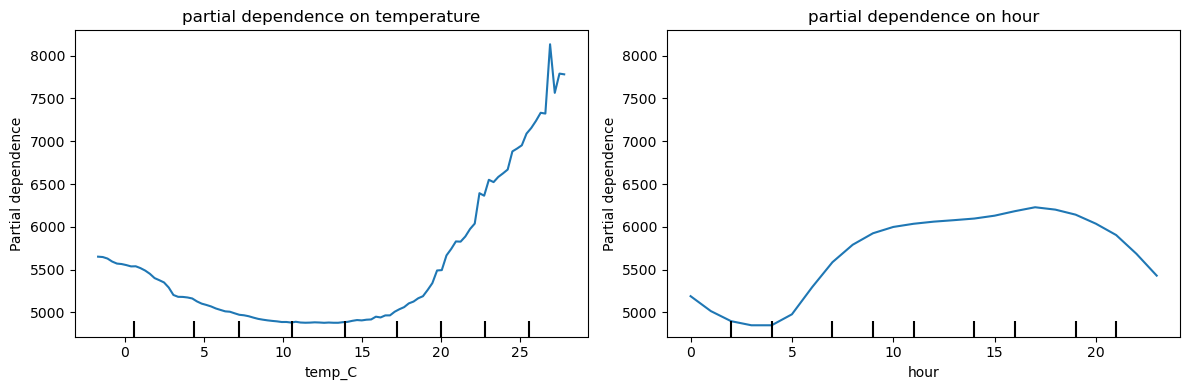

In [12]:
from sklearn.inspection import PartialDependenceDisplay

importance = pd.Series(forest.feature_importances_, index=features).sort_values(ascending=False)
print("feature importance:")
print(importance.round(3).to_string())

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(forest, X_train, features=[0, 1], feature_names=features, ax=axs)
axs[0].set_title("partial dependence on temperature"); axs[1].set_title("partial dependence on hour")
plt.tight_layout(); plt.show()

Temperature carries about two thirds of the importance and hour of day most of the rest. The
partial dependence on temperature is the U from Section 2, learned from the data with no one
telling the model it should be a U: a shallow decline to about 15 °C, then a steep rise. The
hour panel is the daily cycle, with the evening peak. A straight line could not have produced
either picture.

## 8. The thing trees cannot do

A forest's prediction is always an average of training targets. Ask it about a temperature
hotter than any it has seen and it finds the leaf for the hottest hours it knows and returns
their average. It cannot go higher. The straight line, wrong as it is, at least keeps going.

Below, both models predict the 4 pm load on a July weekday across a range of temperatures,
including ones that have never occurred at Central Park. The dashed line is the hottest hour in
the training years.


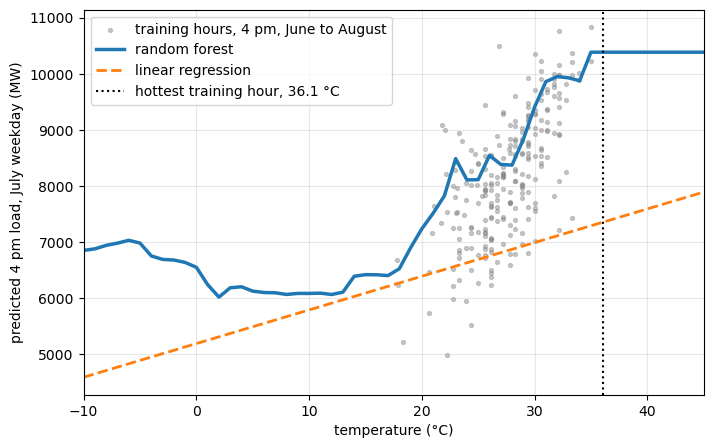

30 °C:  forest 9,403 MW   linear 6,985 MW
35 °C:  forest 10,384 MW   linear 7,285 MW
40 °C:  forest 10,384 MW   linear 7,586 MW
45 °C:  forest 10,384 MW   linear 7,886 MW


In [13]:
temps = np.arange(-10, 46, 1.0)
probe = pd.DataFrame({"temp_C": temps, "hour": 16, "dayofweek": 2, "doy": 200})[features].values

fig, ax = plt.subplots(figsize=(8, 5))
hot_july = train[(train["hour"] == 16) & (train["doy"].between(170, 230))]
ax.scatter(hot_july["temp_C"], hot_july["load_MW"], s=8, alpha=0.4, color="gray", label="training hours, 4 pm, June to August")
ax.plot(temps, forest.predict(probe), lw=2.5, label="random forest")
ax.plot(temps, lin.predict(probe), lw=2, ls="--", label="linear regression")
ax.axvline(train["temp_C"].max(), color="k", ls=":", label=f"hottest training hour, {train['temp_C'].max():.1f} °C")
ax.set_xlabel("temperature (°C)"); ax.set_ylabel("predicted 4 pm load, July weekday (MW)")
ax.set_xlim(-10, 45); ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.show()

for T in [30, 35, 40, 45]:
    row = pd.DataFrame({"temp_C": [T], "hour": 16, "dayofweek": 2, "doy": 200})[features].values
    print(f"{T} °C:  forest {forest.predict(row)[0]:,.0f} MW   linear {lin.predict(row)[0]:,.0f} MW")

Inside the range of the data the forest is excellent and the line is not. Past the hottest
training hour the forest is a horizontal line: 40 °C and 45 °C get the same answer as 36 °C,
because no training hour was hotter and the leaves have nothing else to average. The physics
says demand keeps climbing. A tree model cannot say so.

This is the central caution for using trees in climate work. Any question about conditions
outside the historical record, a warmer climate, a record heat wave, a higher sea level, is a
question a forest will answer with the edge of its training data and no warning. Models that
extrapolate, linear and physical models among them, may be wrong in a different way, but they
at least move. The right response is to know which regime your question lives in, and to say so.

**The same failure on a record you know.** The Mauna Loa CO₂ series from Assignment 2, fitted
on everything up to 2010 and asked about the years since.


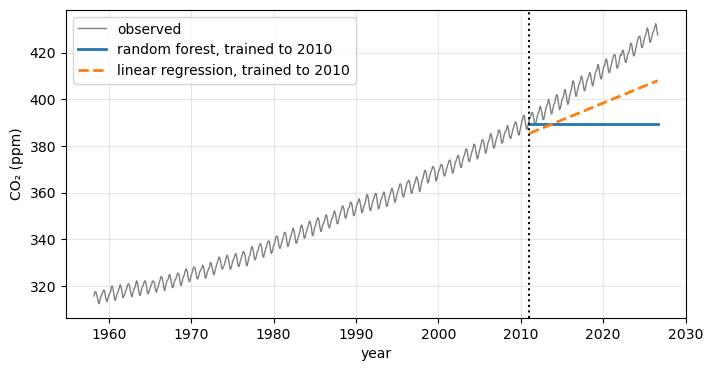

most recent observation 427.6 ppm; forest says 389.5, line says 408.0


In [14]:
co2 = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv", comment="#")
co2 = co2[co2["average"] > 0]
t, y = co2["decimal date"].values.reshape(-1, 1), co2["average"].values
fit = t[:, 0] < 2011

rf_co2 = RandomForestRegressor(n_estimators=100, random_state=42).fit(t[fit], y[fit])
lin_co2 = LinearRegression().fit(t[fit], y[fit])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, y, color="gray", lw=1, label="observed")
ax.plot(t[~fit], rf_co2.predict(t[~fit]), lw=2, label="random forest, trained to 2010")
ax.plot(t[~fit], lin_co2.predict(t[~fit]), lw=2, ls="--", label="linear regression, trained to 2010")
ax.axvline(2011, color="k", ls=":")
ax.set_xlabel("year"); ax.set_ylabel("CO₂ (ppm)"); ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.show()
print(f"most recent observation {y[-1]:.1f} ppm; forest says {rf_co2.predict(t[-1:])[0]:.1f}, line says {lin_co2.predict(t[-1:])[0]:.1f}")

The forest stops dead at the last value it was trained on and stays there for fifteen years.
The straight line is low too, by about 20 ppm, because the real curve bends upward. The forest
is low by nearly 40, the entire increase since 2010.

## Where this goes next

The recipe did not change from Week 4: features and a target, a split that respects time, fit,
predict, score against a baseline a person could produce. What changed is the model family, and
with it two things: a forest can learn a shape nobody specified, and it cannot leave the range
of its training data. Assignment 5 applies the same models, classifier and regressor, to air
quality, and Week 6 is about making the validation itself trustworthy.

## Exercises

1. **Humidity.** NOAA's hourly feed also carries dew point (`DEW`, same encoding as `TMP`).
   Add it as a feature, retrain the forest, and report the change in validation RMSE. Does the
   partial dependence on temperature change shape?


2. **Holidays.** Demand on Thanksgiving looks like a Sunday, and the model does not know. Add a
   binary feature for US federal holidays (`pandas.tseries.holiday.USFederalHolidayCalendar`),
   retrain, and look at the residuals on those days before and after.


3. **Minimum leaf size.** Instead of limiting depth, train `DecisionTreeRegressor` with
   `min_samples_leaf` of 10, 50, and 200 and no depth limit. Compare the validation RMSE and the
   training-validation gap with the depth-limited best tree.


4. **Test year, finally.** Report the forest's RMSE on 2024, the held-out year. Then plot
   predicted against observed load for the hottest week of 2024. Where is the error largest, and
   does Section 8 explain it?


5. **A warmer city.** Add 3 °C to every temperature in the 2024 test set and predict with the
   forest. By how much does predicted annual peak load rise, and why is that number an
   underestimate?


6. **A model that extrapolates.** Fit a polynomial regression of degree 2 or 3 on temperature
   and hour (`PolynomialFeatures` from Week 4) and add it to the Section 8 plot. Does it beat the
   forest inside the data? Outside?
